<a href="https://colab.research.google.com/github/jelaenas/CESISTA-KJ-DSC1107/blob/main/CESISTA_FA_3_GROUP_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(tidyverse)
install.packages("ggrepel") # Install ggrepel package
library(ggrepel)
library(broom)
install.packages("cowplot") # Install cowplot package
library(cowplot)
install.packages("car") # Install car package
library(car) # for VIF & diagnostics
install.packages("performance") # Install performance package
library(performance) # optional for model checks

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘insight’, ‘datawizard’




**Part 1 – Data Wrangling and Validation** (6 points)
1.1 Import & Structure (2 points)
Import as mlb_raw.

Report dimensions and variable types.

In [ ]:
load("/content/ml_pay.rdata")

ls()

[1] "ml_pay"

In [42]:
#Import as mlb_raw
mlb_raw <- ml_pay

# Report dimensions and variable types
glimpse(mlb_raw)

Rows: 30
Columns: 54
$ payroll        <dbl> 1.1208736, 1.3817118, 1.1612117, 1.9723587, 1.4597668, …
$ avgwin         <dbl> 0.4902585, 0.5527605, 0.4538250, 0.5487172, 0.4736557, …
$ Team.name.2014 <fct> Arizona Diamondbacks, Atlanta Braves, Baltimore Orioles…
$ p1998          <dbl> 31.61450, 61.70800, 71.86092, 59.49700, 49.81600, 35.18…
$ p1999          <dbl> 70.49600, 74.89000, 72.19836, 71.72500, 42.14276, 24.53…
$ p2000          <dbl> 81.02783, 84.53784, 81.44743, 77.94033, 60.53933, 31.13…
$ p2001          <dbl> 81.20651, 91.85169, 72.42633, 109.55891, 64.01583, 62.3…
$ p2002          <dbl> 102.82000, 93.47037, 60.49349, 108.36606, 75.69083, 57.…
$ p2003          <dbl> 80.64033, 106.24367, 73.87750, 99.94650, 79.86833, 51.0…
$ p2004          <dbl> 70.20498, 88.50779, 51.21265, 125.20854, 91.10167, 65.2…
$ p2005          <dbl> 63.01583, 85.14858, 74.57054, 121.31194, 87.21093, 75.2…
$ p2006          <dbl> 59.68423, 90.15688, 72.58558, 120.09982, 94.42450, 102.…
$ p2007          <d

Briefly comment on structure.

The dataset has 30 rows and 54 column, where each row represents a MLB team, and the columns have their payroll, wins, and win percentage from 1998 to 2014. Also, it is currently in a wide format because every year has a separate column.

**1.2 Tidy Data (4 points)**

**Create:**
**mlb_aggregate**

team

payroll_aggregate

pct_wins_aggregate

**mlb_yearly**

team

year

payroll

pct_wins

num_wins

Explain why mlb_yearly should contain 30 × 17 row

In [45]:
# aggregate
mlb_aggregate <- mlb_raw %>%
  rowwise() %>%
  mutate(
    payroll_aggregate = sum(c_across(p1998:p2014), na.rm = TRUE),
    pct_wins_aggregate = mean(c_across(matches("^X\\d{4}\\.pct$")), na.rm = TRUE)
  ) %>%
  ungroup() %>%
  select(team = Team.name.2014, payroll_aggregate, pct_wins_aggregate)

glimpse(mlb_aggregate)

Rows: 30
Columns: 3
$ team               <fct> Arizona Diamondbacks, Atlanta Braves, Baltimore Ori…
$ payroll_aggregate  <dbl> 1222.9841, 1518.3098, 1305.2710, 2103.5807, 1551.72…
$ pct_wins_aggregate <dbl> 0.4921264, 0.5631539, 0.4570920, 0.5512860, 0.47458…


In [46]:

# yearly payroll
mlb_yearly_payroll <- mlb_raw %>%
  select(team = Team.name.2014, matches("^p\\d{4}$")) %>%
  pivot_longer(
    cols = matches("^p\\d{4}$"),
    names_to = "year",
    names_prefix = "p",
    values_to = "payroll"
  ) %>%
  mutate(year = as.integer(year))

# yearly wins
mlb_yearly_wins <- mlb_raw %>%
  select(team = Team.name.2014, matches("^X\\d{4}$")) %>%
  pivot_longer(
    cols = matches("^X\\d{4}$"),
    names_to = "year",
    names_prefix = "X",
    values_to = "num_wins"
  ) %>%
  mutate(year = as.integer(year))

# yearly win percentage
mlb_yearly_pct <- mlb_raw %>%
  select(team = Team.name.2014, matches("^X\\d{4}\\.pct$")) %>%
  pivot_longer(
    cols = matches("^X\\d{4}\\.pct$"),
    names_to = "year",
    names_pattern = "X(\\d{4})\\.pct",
    values_to = "pct_wins"
  ) %>%
  mutate(year = as.integer(year))

# combine for mlb_yearly
mlb_yearly <- mlb_yearly_payroll %>%
  inner_join(mlb_yearly_wins, by = c("team", "year")) %>%
  inner_join(mlb_yearly_pct, by = c("team", "year")) %>%
  select(team, year, payroll, pct_wins, num_wins) %>%
  arrange(team, year)

glimpse(mlb_yearly)

Rows: 510
Columns: 5
$ team     <fct> Arizona Diamondbacks, Arizona Diamondbacks, Arizona Diamondba…
$ year     <int> 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2…
$ payroll  <dbl> 31.61450, 70.49600, 81.02783, 81.20651, 102.82000, 80.64033, …
$ pct_wins <dbl> 0.3987730, 0.6134969, 0.5246914, 0.5679012, 0.6049383, 0.5185…
$ num_wins <int> 65, 100, 85, 92, 98, 84, 51, 77, 76, 90, 82, 70, 65, 94, 81, …


Explain why mlb_yearly should contain 30 × 17 row.

There are 30 teams, and the dataset is from 1998 to 2014 which is 17 years. It should contain 30 x 17 rows since each row represents the payroll, pct_wins, and num_wins of a team in one year.

**Part 2 – Aggregate Consistency Check (4 points)**
Compute aggregates from mlb_yearly.

Join with provided aggregates.

Produce scatter plots:

computed vs provided payroll

computed vs provided win percentage

Add 45° reference lines.

Comment on numerical differences (if any).

Rows: 30
Columns: 3
$ team               <fct> Arizona Diamondbacks, Atlanta Braves, Baltimore Ori…
$ payroll_aggregate  <dbl> 1222.9841, 1518.3098, 1305.2710, 2103.5807, 1551.72…
$ pct_wins_aggregate <dbl> 0.4921264, 0.5631539, 0.4570920, 0.5512860, 0.47458…


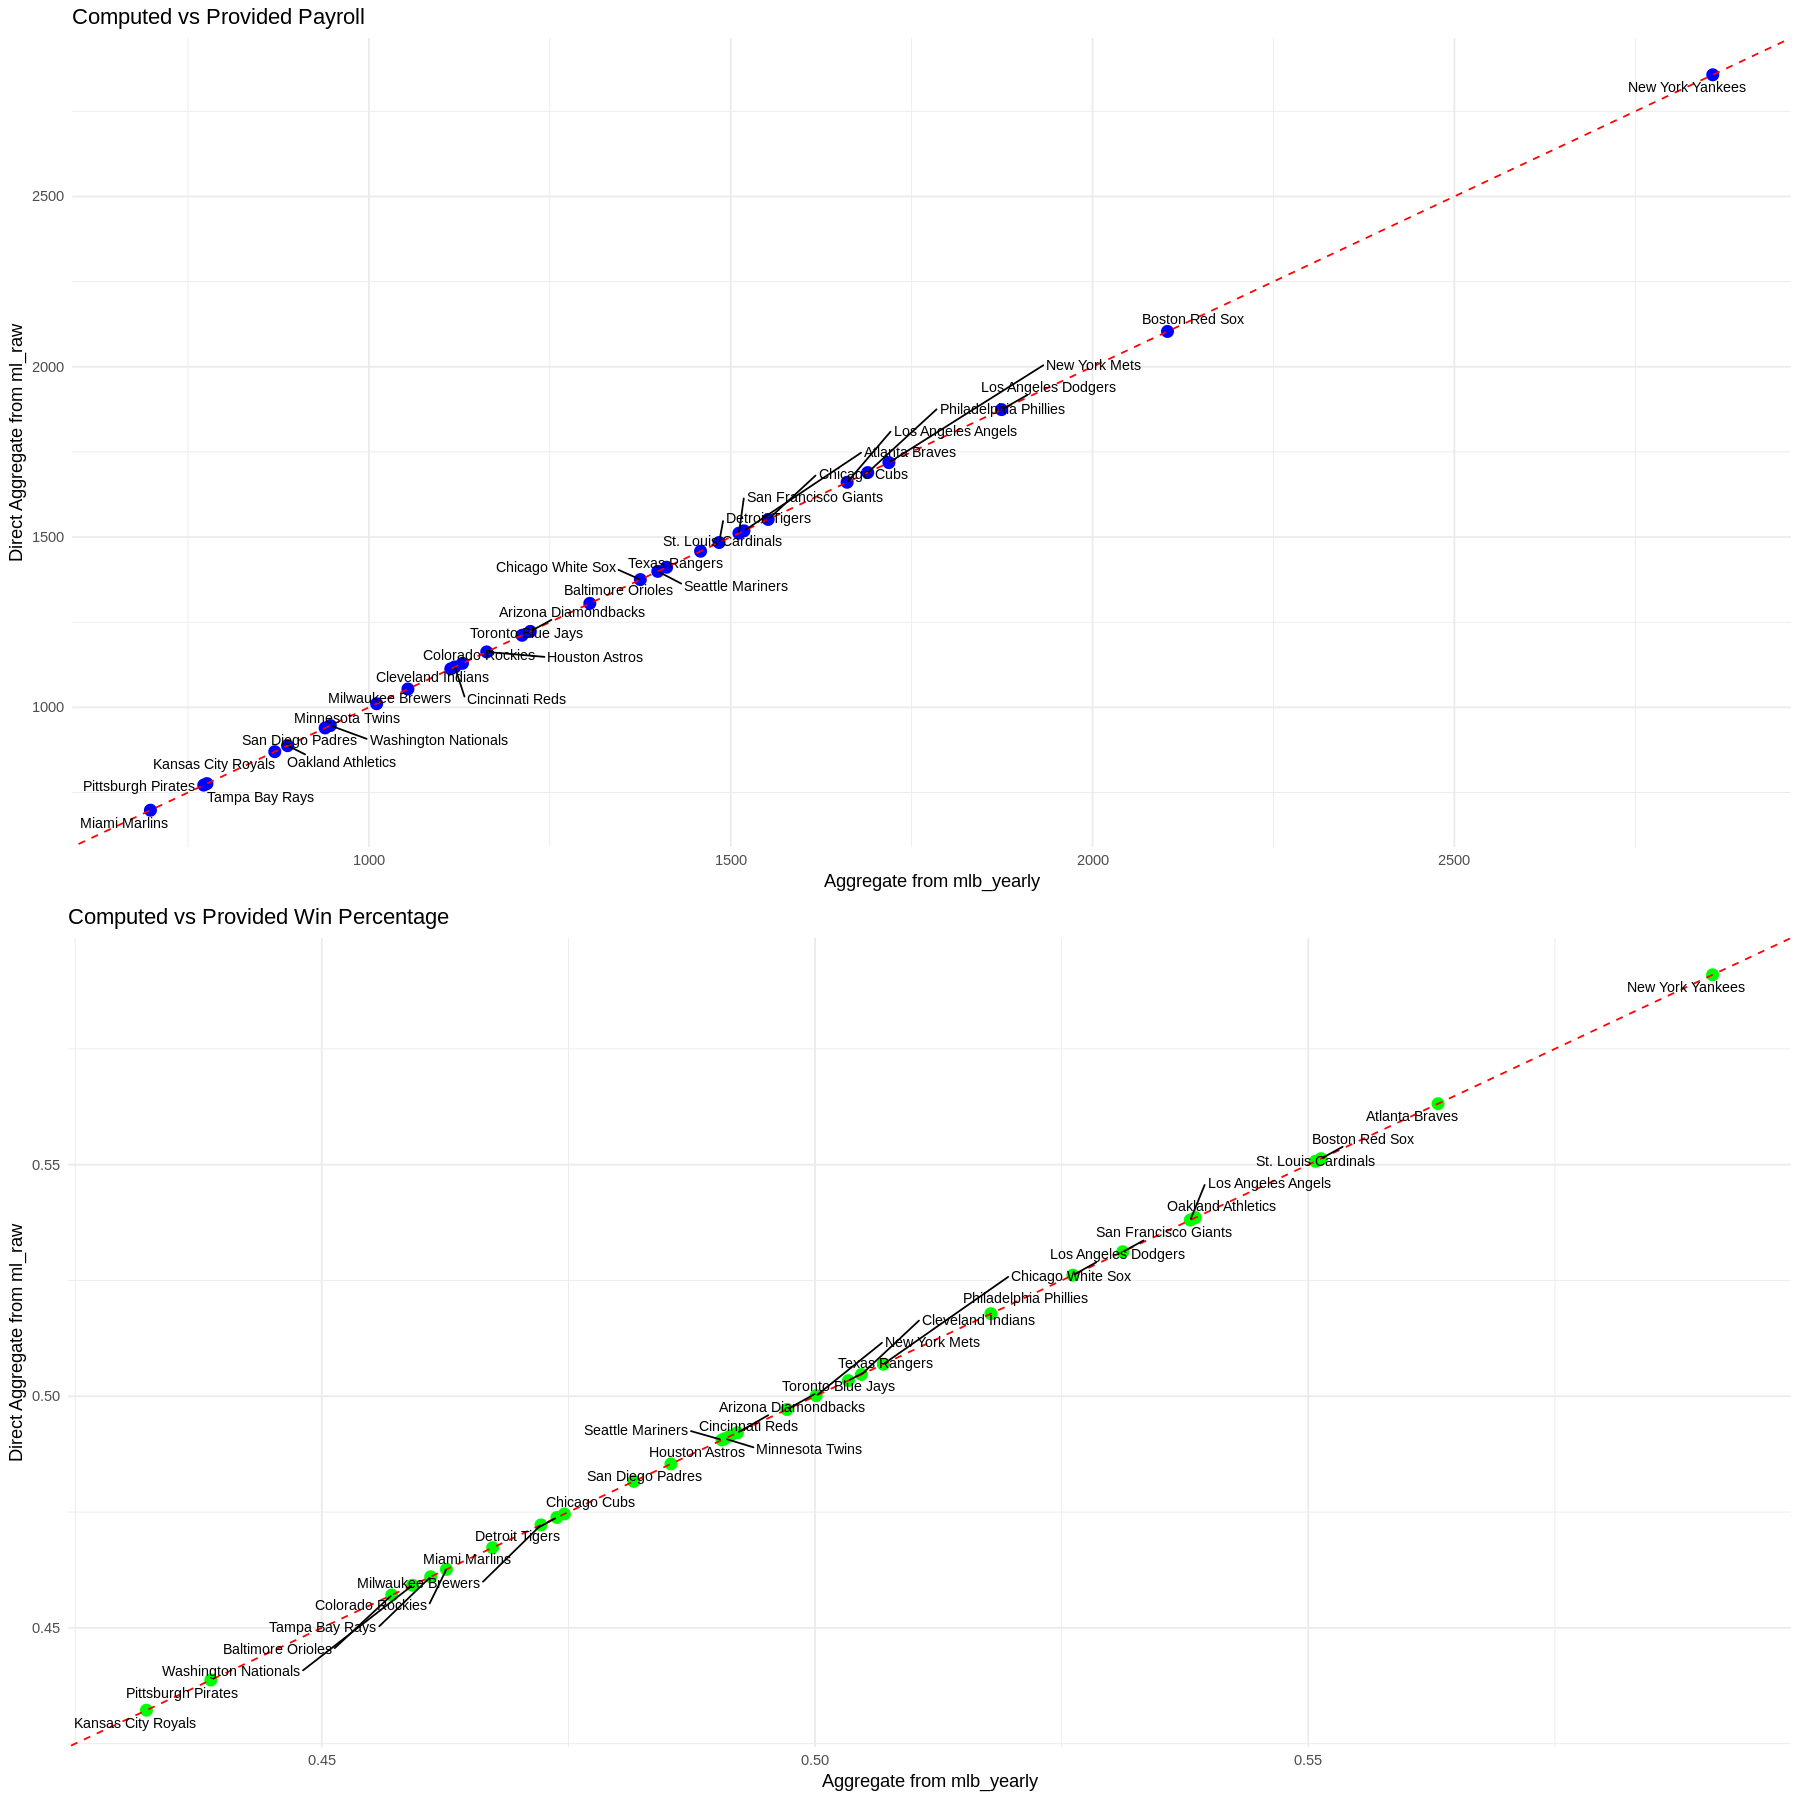

In [48]:
mlb_aggregate_from_yearly <- mlb_yearly %>%
  group_by(team) %>%
  summarise(
    payroll_aggregate = sum(payroll, na.rm = TRUE),
    pct_wins_aggregate = mean(pct_wins, na.rm = TRUE)
  ) %>%
  ungroup()

glimpse(mlb_aggregate_from_yearly)

#compare aggregates
mlb_aggregate_compare <- mlb_aggregate %>%
  inner_join(mlb_aggregate_from_yearly, by = "team", suffix = c("_yearly", "_direct"))

options(repr.plot.width = 15, repr.plot.height = 15)

# scatter plots wth 45 degree reference line

p1 <- ggplot(mlb_aggregate_compare, aes(x = payroll_aggregate_yearly, y = payroll_aggregate_direct)) +
  geom_point(color = "blue", size = 3) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  geom_text_repel(aes(label = team), max.overlaps = 50, size = 3) +
  labs(
    title = "Computed vs Provided Payroll",
    x = "Aggregate from mlb_yearly",
    y = "Direct Aggregate from ml_raw"
  ) +
  theme_minimal()

p2 <- ggplot(mlb_aggregate_compare, aes(x = pct_wins_aggregate_yearly, y = pct_wins_aggregate_direct)) +
  geom_point(color = "green", size = 3) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  geom_text_repel(aes(label = team), max.overlaps = 50, size = 3) +
  labs(
    title = "Computed vs Provided Win Percentage",
    x = "Aggregate from mlb_yearly",
    y = "Direct Aggregate from ml_raw"
  ) +
  theme_minimal()

plot_grid(p1, p2, ncol = 1)

Comment on numerical differences.

A good amount of the points lie on the 45 degree reference line, meaning for those points there are no numerical difference from the different methods of getting the aggregate. The other points still lie close to the reference line, meaning that the numerical difference is not big, and may becaused from missing values or from rounding.


# Part 3 – Exploratory Data Analysis (6 points)
3.1 Trends Over Time (3 points)
Faceted payroll vs year plot.

Faceted win percentage vs year plot.

Identify:

3 highest payroll teams

3 highest win percentage teams

Provide short interpretation (≤5 sentences).

[1] "The team with the highest aggregated payrolls are:"


team,payroll_aggregate,pct_wins_aggregate
<fct>,<dbl>,<dbl>
New York Yankees,2857.093,0.5909819
Boston Red Sox,2103.581,0.5512860
Los Angeles Dodgers,1874.194,0.5261364


[1] "The team with the highest winning percentage are:"


team,pct_wins_aggregate,payroll_aggregate
<fct>,<dbl>,<dbl>
New York Yankees,0.5909819,2857.093
Atlanta Braves,0.5631539,1518.310
Boston Red Sox,0.5512860,2103.581


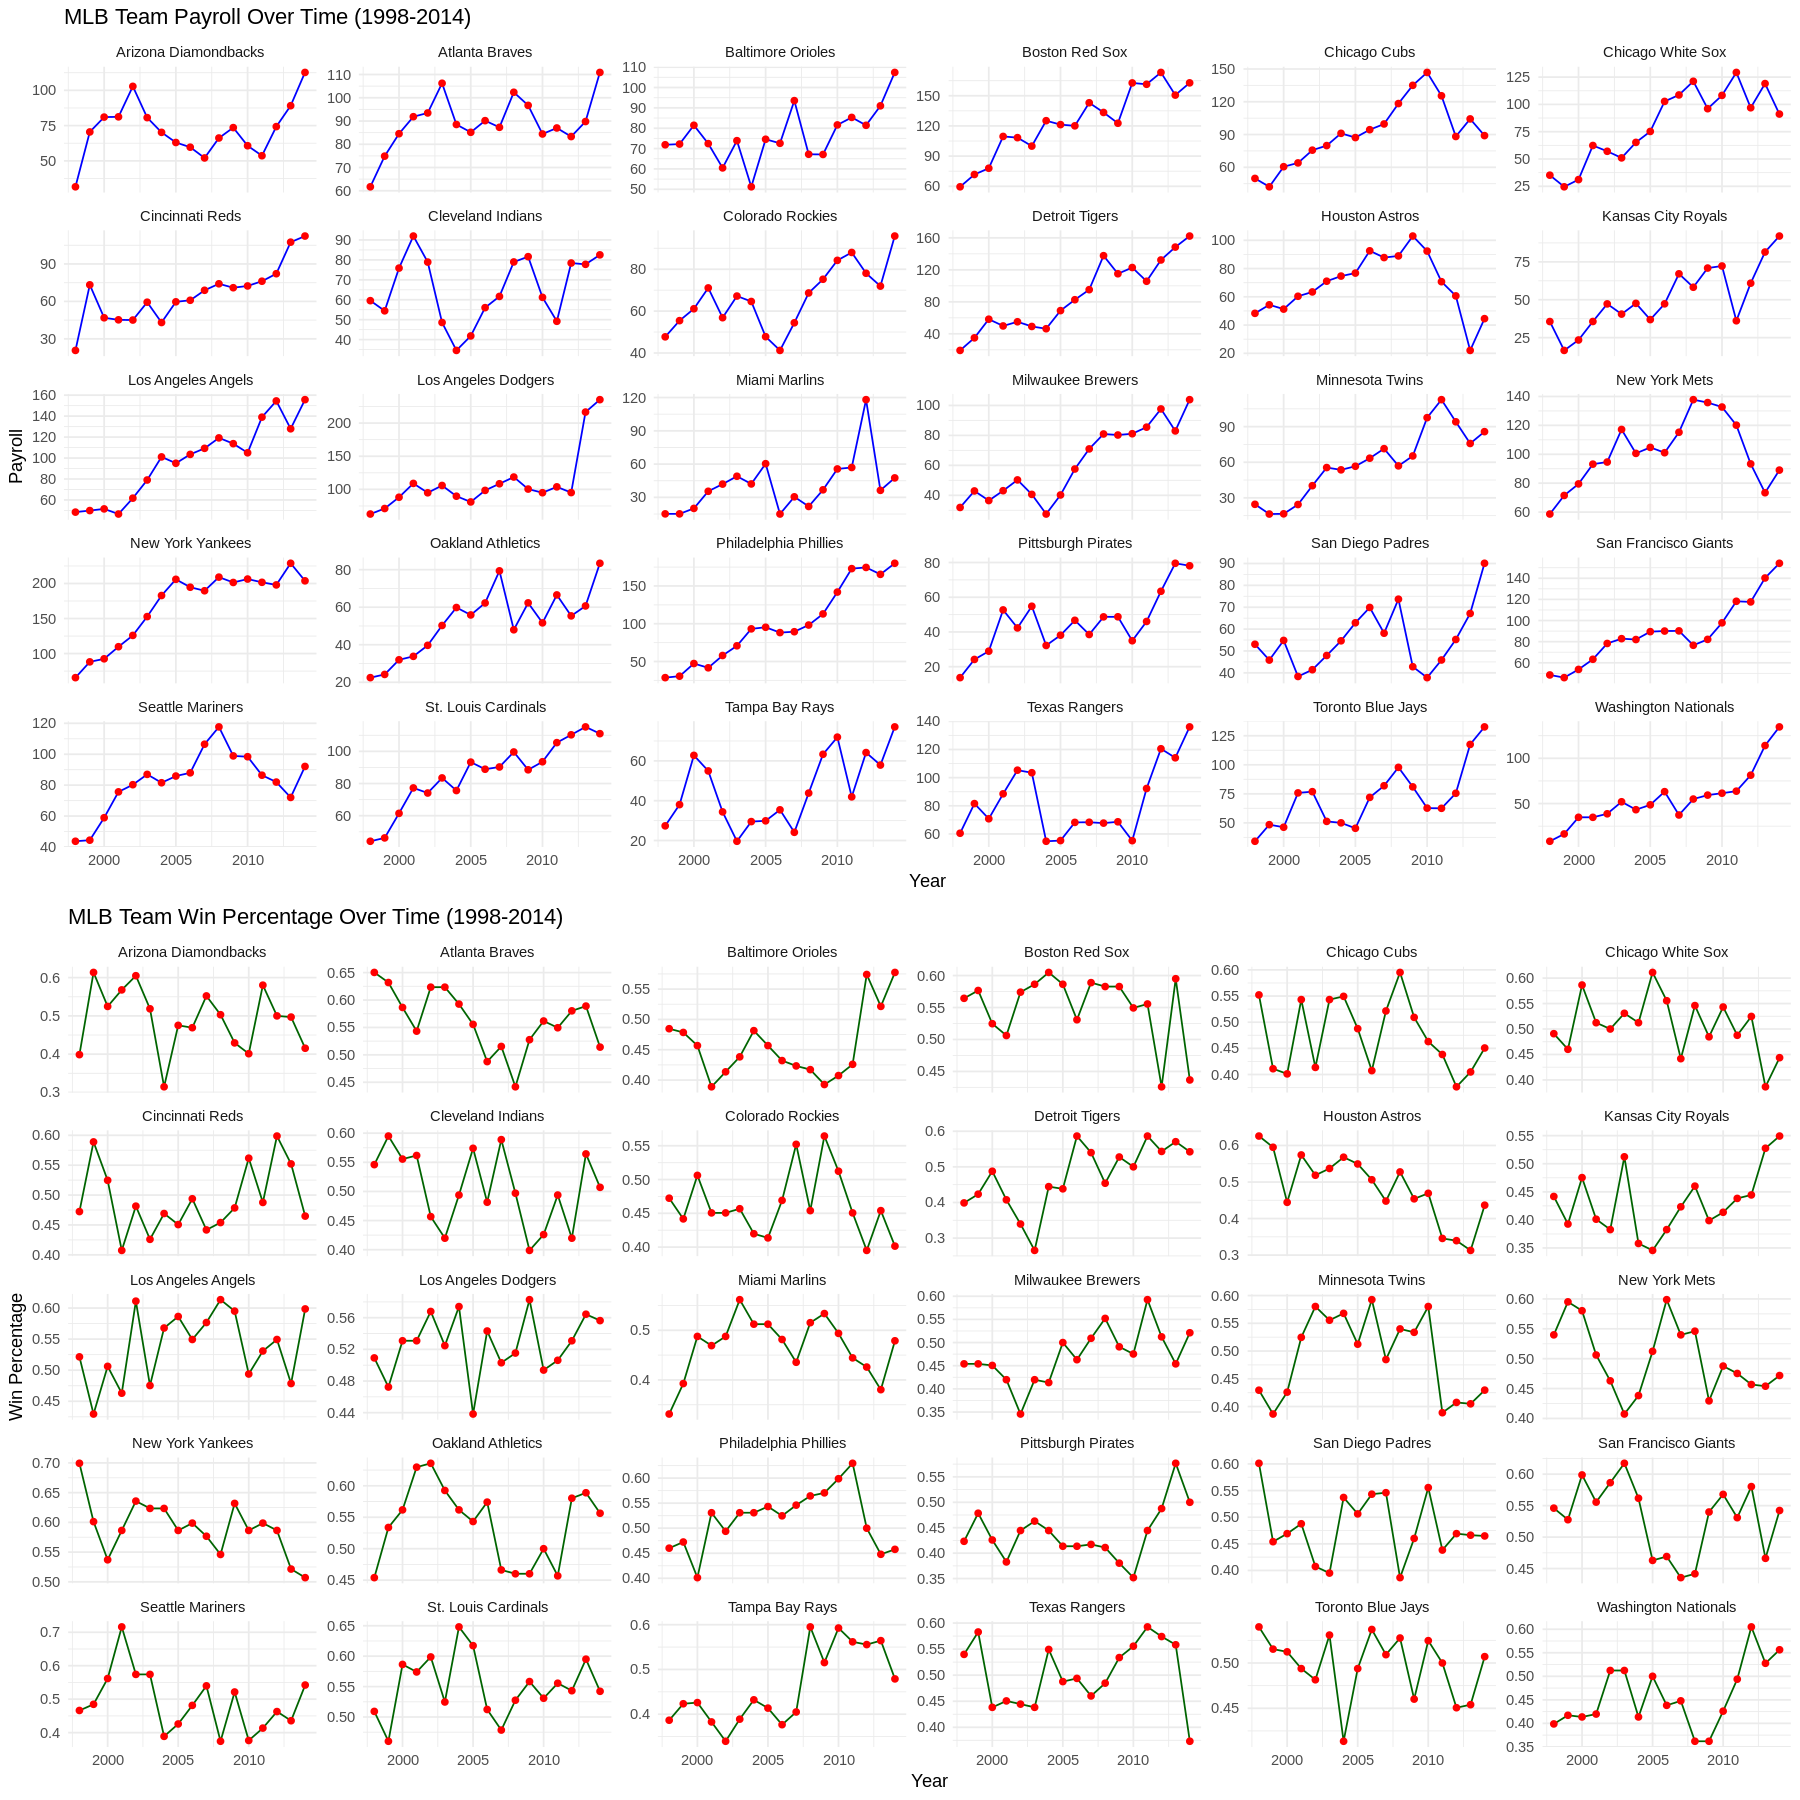

In [58]:
# faceted payroll vs year
p_payroll <- ggplot(mlb_yearly, aes(x = year, y = payroll)) +
  geom_line(color = "blue") +
  geom_point(color = "red") +
  facet_wrap(~team, scales = "free_y") +
  labs(title = "MLB Team Payroll Over Time (1998-2014)",
       x = "Year", y = "Payroll") +
  theme_minimal()

# faceted win percentage vs year
p_pct_wins <- ggplot(mlb_yearly, aes(x = year, y = pct_wins)) +
  geom_line(color = "dark green") +
  geom_point(color = "red") +
  facet_wrap(~team, scales = "free_y") +
  labs(title = "MLB Team Win Percentage Over Time (1998-2014)",
       x = "Year", y = "Win Percentage") +
  theme_minimal()

plot_grid(p_payroll, p_pct_wins, ncol = 1)

# 3 highest payroll teams
top3_payroll <- mlb_aggregate %>%
  arrange(desc(payroll_aggregate)) %>%
  slice(1:3)

# 3 highest win percentage teams

top3_win_pct <- mlb_aggregate %>%
  arrange(desc(pct_wins_aggregate)) %>%
  slice(1:3) %>%
  relocate(last_col(), .before = last_col(offset = 1))

print("The team with the highest aggregated payrolls are:")

top3_payroll

print("The team with the highest winning percentage are:")
top3_win_pct

Provide short interpretation (≤5 sentences).
New York Yankees has both the highest aggregated payroll and winning percentage, while the Boston Red Sox has the second highest payroll and third highest winning percentage. This implies that a team's payroll is impacted by their winning percentage.

3.2 Correlation Analysis (3 points)
Compute Pearson correlation between aggregate payroll and aggregate win percentage.

Test for statistical significance.

Interpret magnitude (weak/moderate/strong).

In [59]:
cor_test <- cor.test(
  ~ payroll_aggregate + pct_wins_aggregate,
  data = mlb_aggregate,
  method = "pearson"
)

cor_test


	Pearson's product-moment correlation

data:  payroll_aggregate and pct_wins_aggregate
t = 5.7872, df = 28, p-value = 3.249e-06
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5145500 0.8675996
sample estimates:
      cor 
0.7380096 


p-value = 3.249e-06 < 0.001 which shows that th correlation is statistically significant and r = 0.7380096 meaning that there is a strong positive correlation between aggregate payroll and aggregate win percentage. This aligns with the earlier interpretation.

# Part 4 – Regression Modeling (8 points)
4.1 Simple Linear Regression (3 points)

In [63]:
lm_mlb <- lm(pct_wins_aggregate ~ payroll_aggregate, data = mlb_aggregate)
summary(lm_mlb)

confint_lm <- confint(lm_mlb)

slope_ci <- confint_lm[2,]
slope_ci




Call:
lm(formula = pct_wins_aggregate ~ payroll_aggregate, data = mlb_aggregate)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.039888 -0.014780 -0.001019  0.007697  0.067377 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       4.163e-01  1.494e-02  27.864  < 2e-16 ***
payroll_aggregate 6.179e-05  1.068e-05   5.787 3.25e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02588 on 28 degrees of freedom
Multiple R-squared:  0.5447,	Adjusted R-squared:  0.5284 
F-statistic: 33.49 on 1 and 28 DF,  p-value: 3.249e-06


[1] 6.178595e-05

[1] 3.248964e-06

[1] 0.5446582

2.5 %       97.5 % 
3.991671e-05 8.365520e-05

Report:

Estimated slope = 6.179e-05

p-value = 3.25e-06

R² = 0.5447

95% confidence interval for slope - 2.5 %3.99167070380162e-0597.5 %8.36551955984537e-05

Interpret slope in practical terms.

The slope shows the expected increase in win percentage everytime payroll is increased by $1M.

4.2 Regression Diagnostics (3 points)
Produce and interpret:

Residual vs Fitted plot

Q-Q plot

Scale-Location plot

Cook’s Distance

Address:

Linearity

Normality

Homoscedasticity

Influential observations

Comment clearly on whether assumptions are satisfied.

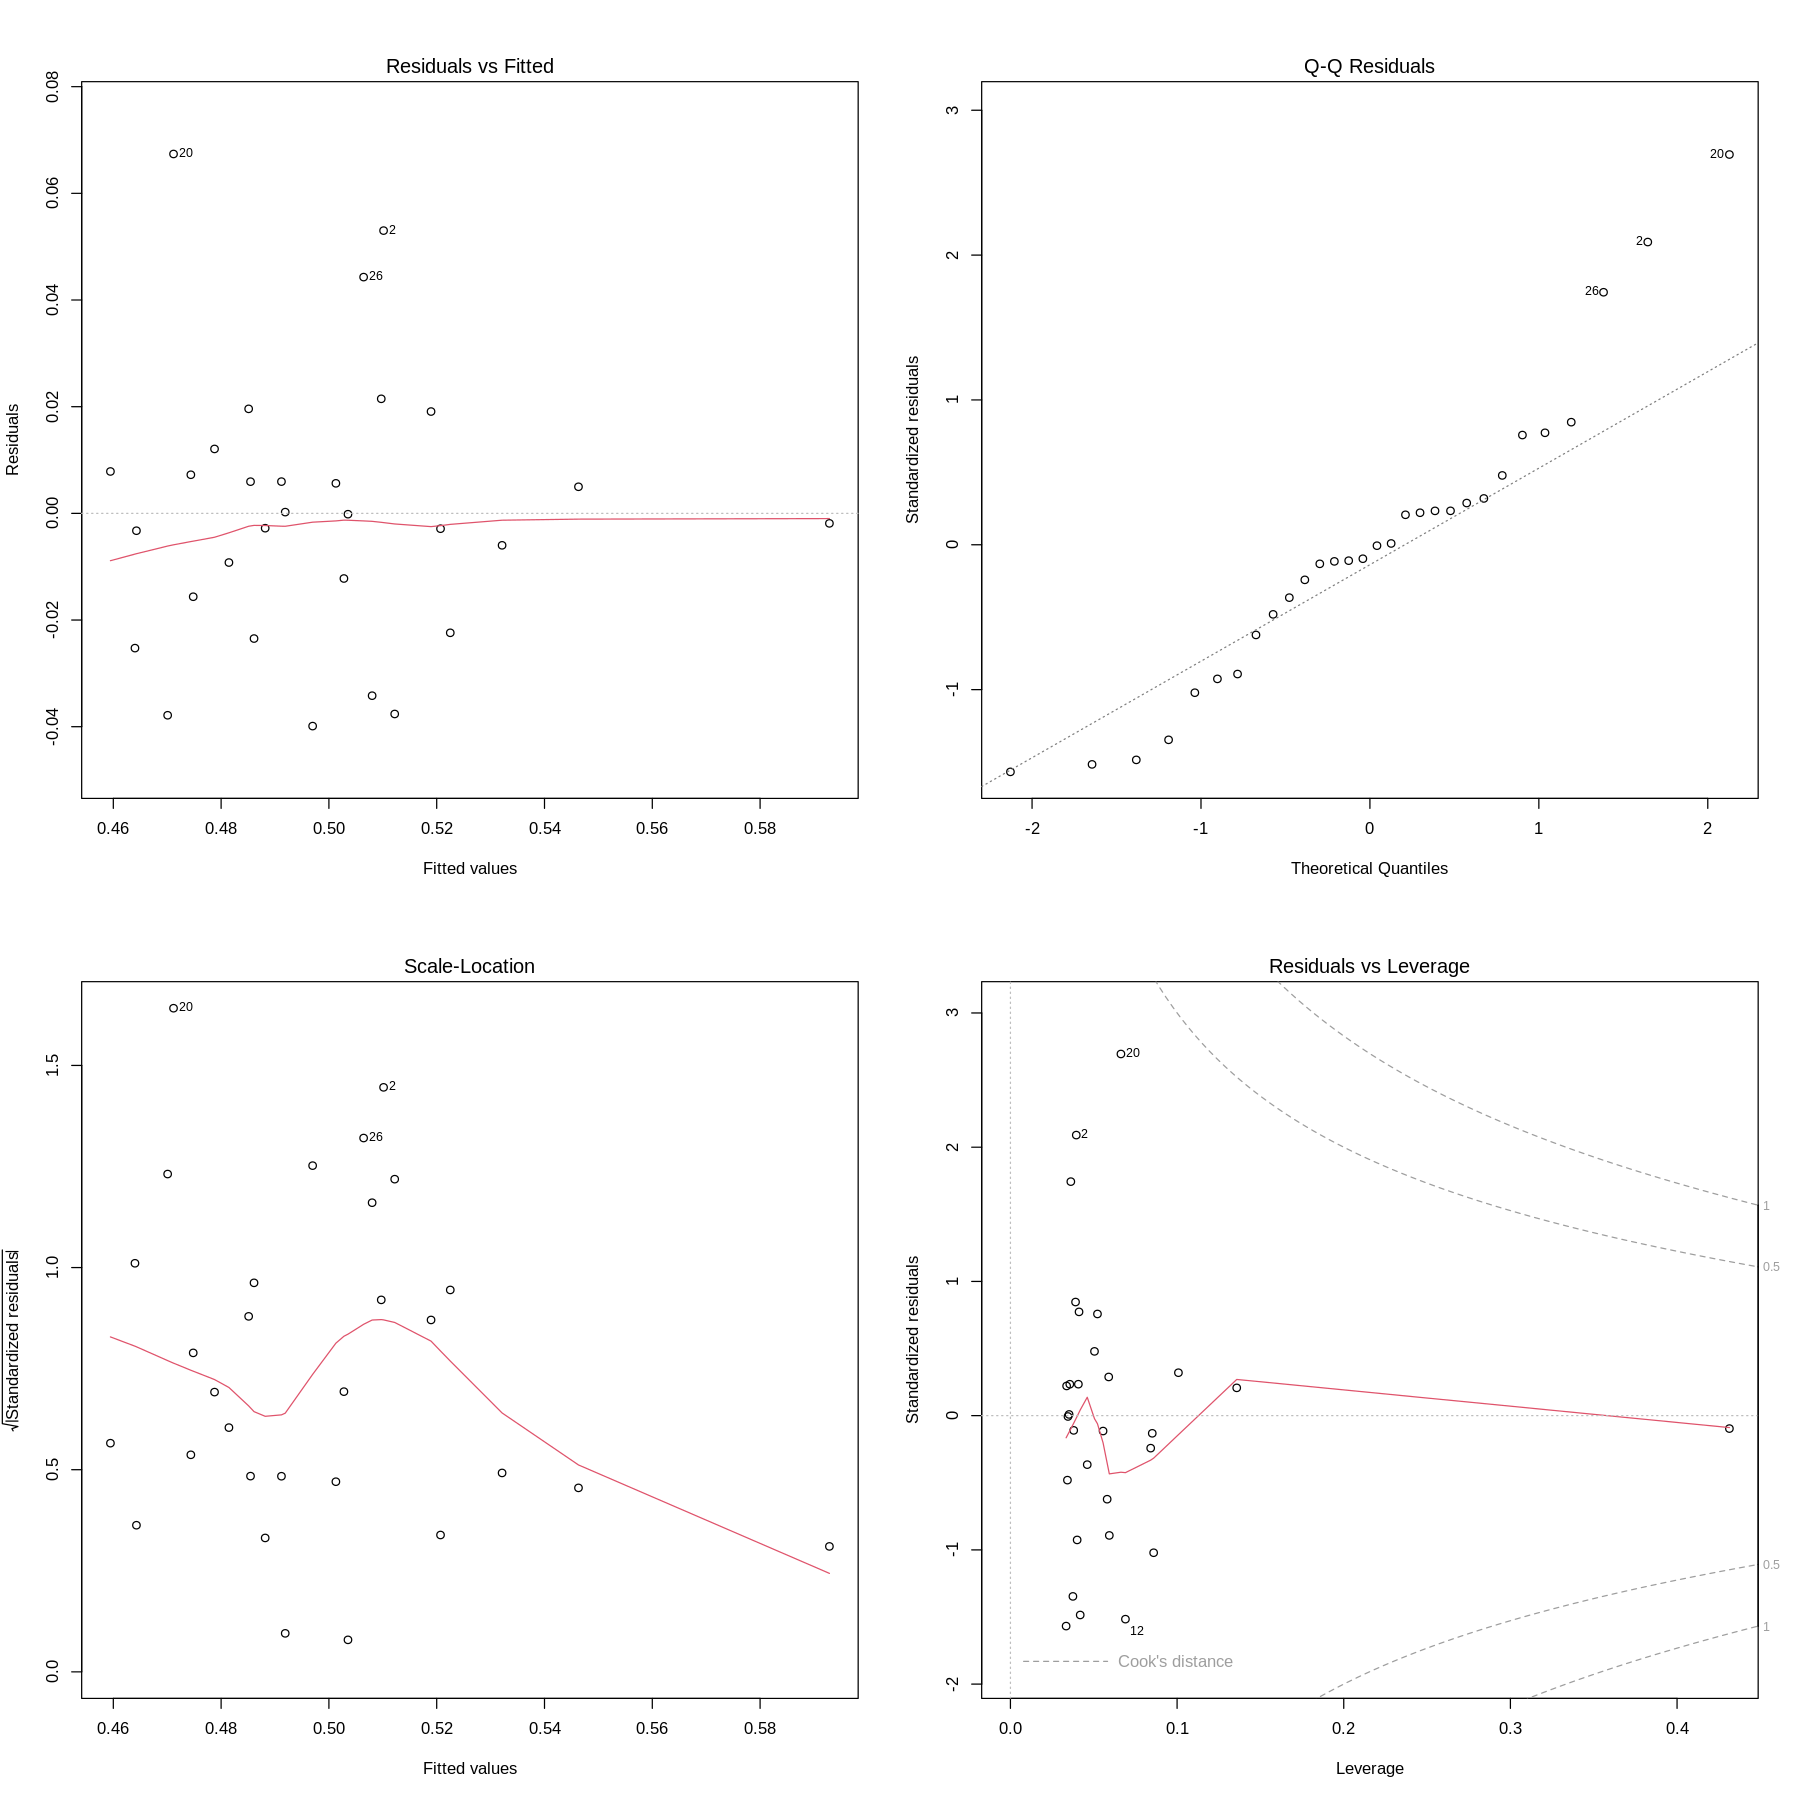

In [64]:
par(mfrow = c(2,2))
plot(lm_mlb)


Linearity is satisfied since the points are randomly scattered around the horizontal line.

Normality is mostly satisified however there is a slight deviation in the upper tail.

Homoscedasticity is violated and there is evidence of heteroscedasticity as the red line is not horizontal and seems to follow a trend.

There seems to be influential observations particularly at 2, 20, and 12.

4.3 Outlier & Influence Analysis (2 points)
Identify any influential teams (high leverage or Cook’s D).

Remove one influential team and refit the model.

Compare slope and R².

Comment on model stability.

In [67]:
cooks_d <- cooks.distance(lm_mlb)
threshold <- 4/(nrow(mlb_aggregate)-2)
influential_teams <- mlb_aggregate$team[cooks_d > threshold]
influential_teams

mlb_refitted <- mlb_aggregate %>% filter(!team %in% influential_teams[1])
lm_refitted <- lm(pct_wins_aggregate ~ payroll_aggregate, data = mlb_no_infl)
summary(lm_refitted)


[1] Oakland Athletics
30 Levels: Arizona Diamondbacks Atlanta Braves ... Washington Nationals


Call:
lm(formula = pct_wins_aggregate ~ payroll_aggregate, data = mlb_no_infl)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.037361 -0.011169  0.001794  0.011739  0.054386 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       4.068e-01  1.346e-02  30.216  < 2e-16 ***
payroll_aggregate 6.719e-05  9.521e-06   7.057 1.38e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02268 on 27 degrees of freedom
Multiple R-squared:  0.6485,	Adjusted R-squared:  0.6354 
F-statistic:  49.8 on 1 and 27 DF,  p-value: 1.378e-07


Before removing influential team :

Estimated slope = 6.179e-05,
R² = 0.5447

After :

Estimated slope = 6.719e-05,
R² = 0.6485.

Model is moderately stable, as removing an influential team changed the slope and R², however it was not a drastic change.

Part 5 – Model Extension and Critical Thinking (4 points)
5.1 Log Transformation (2 points)
Payroll is often right-skewed.

Fit a model using log(payroll_aggregate).

Compare R² and residual behavior.

Does the transformation improve the model?


Call:
lm(formula = pct_wins_aggregate ~ log(payroll_aggregate), data = mlb_aggregate)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.044103 -0.016055 -0.001113  0.015035  0.070427 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -0.11402    0.11084  -1.029    0.312    
log(payroll_aggregate)  0.08575    0.01551   5.530 6.53e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02651 on 28 degrees of freedom
Multiple R-squared:  0.522,	Adjusted R-squared:  0.505 
F-statistic: 30.58 on 1 and 28 DF,  p-value: 6.525e-06


[1] 0.5446582

[1] 0.5220482

team,payroll_aggregate,pct_wins_aggregate,efficiency
<fct>,<dbl>,<dbl>,<dbl>
Miami Marlins,698.0929,0.4673161,0.0006694182
Oakland Athletics,887.5729,0.5385489,0.0006067658
Tampa Bay Rays,776.1869,0.4610341,0.0005939731


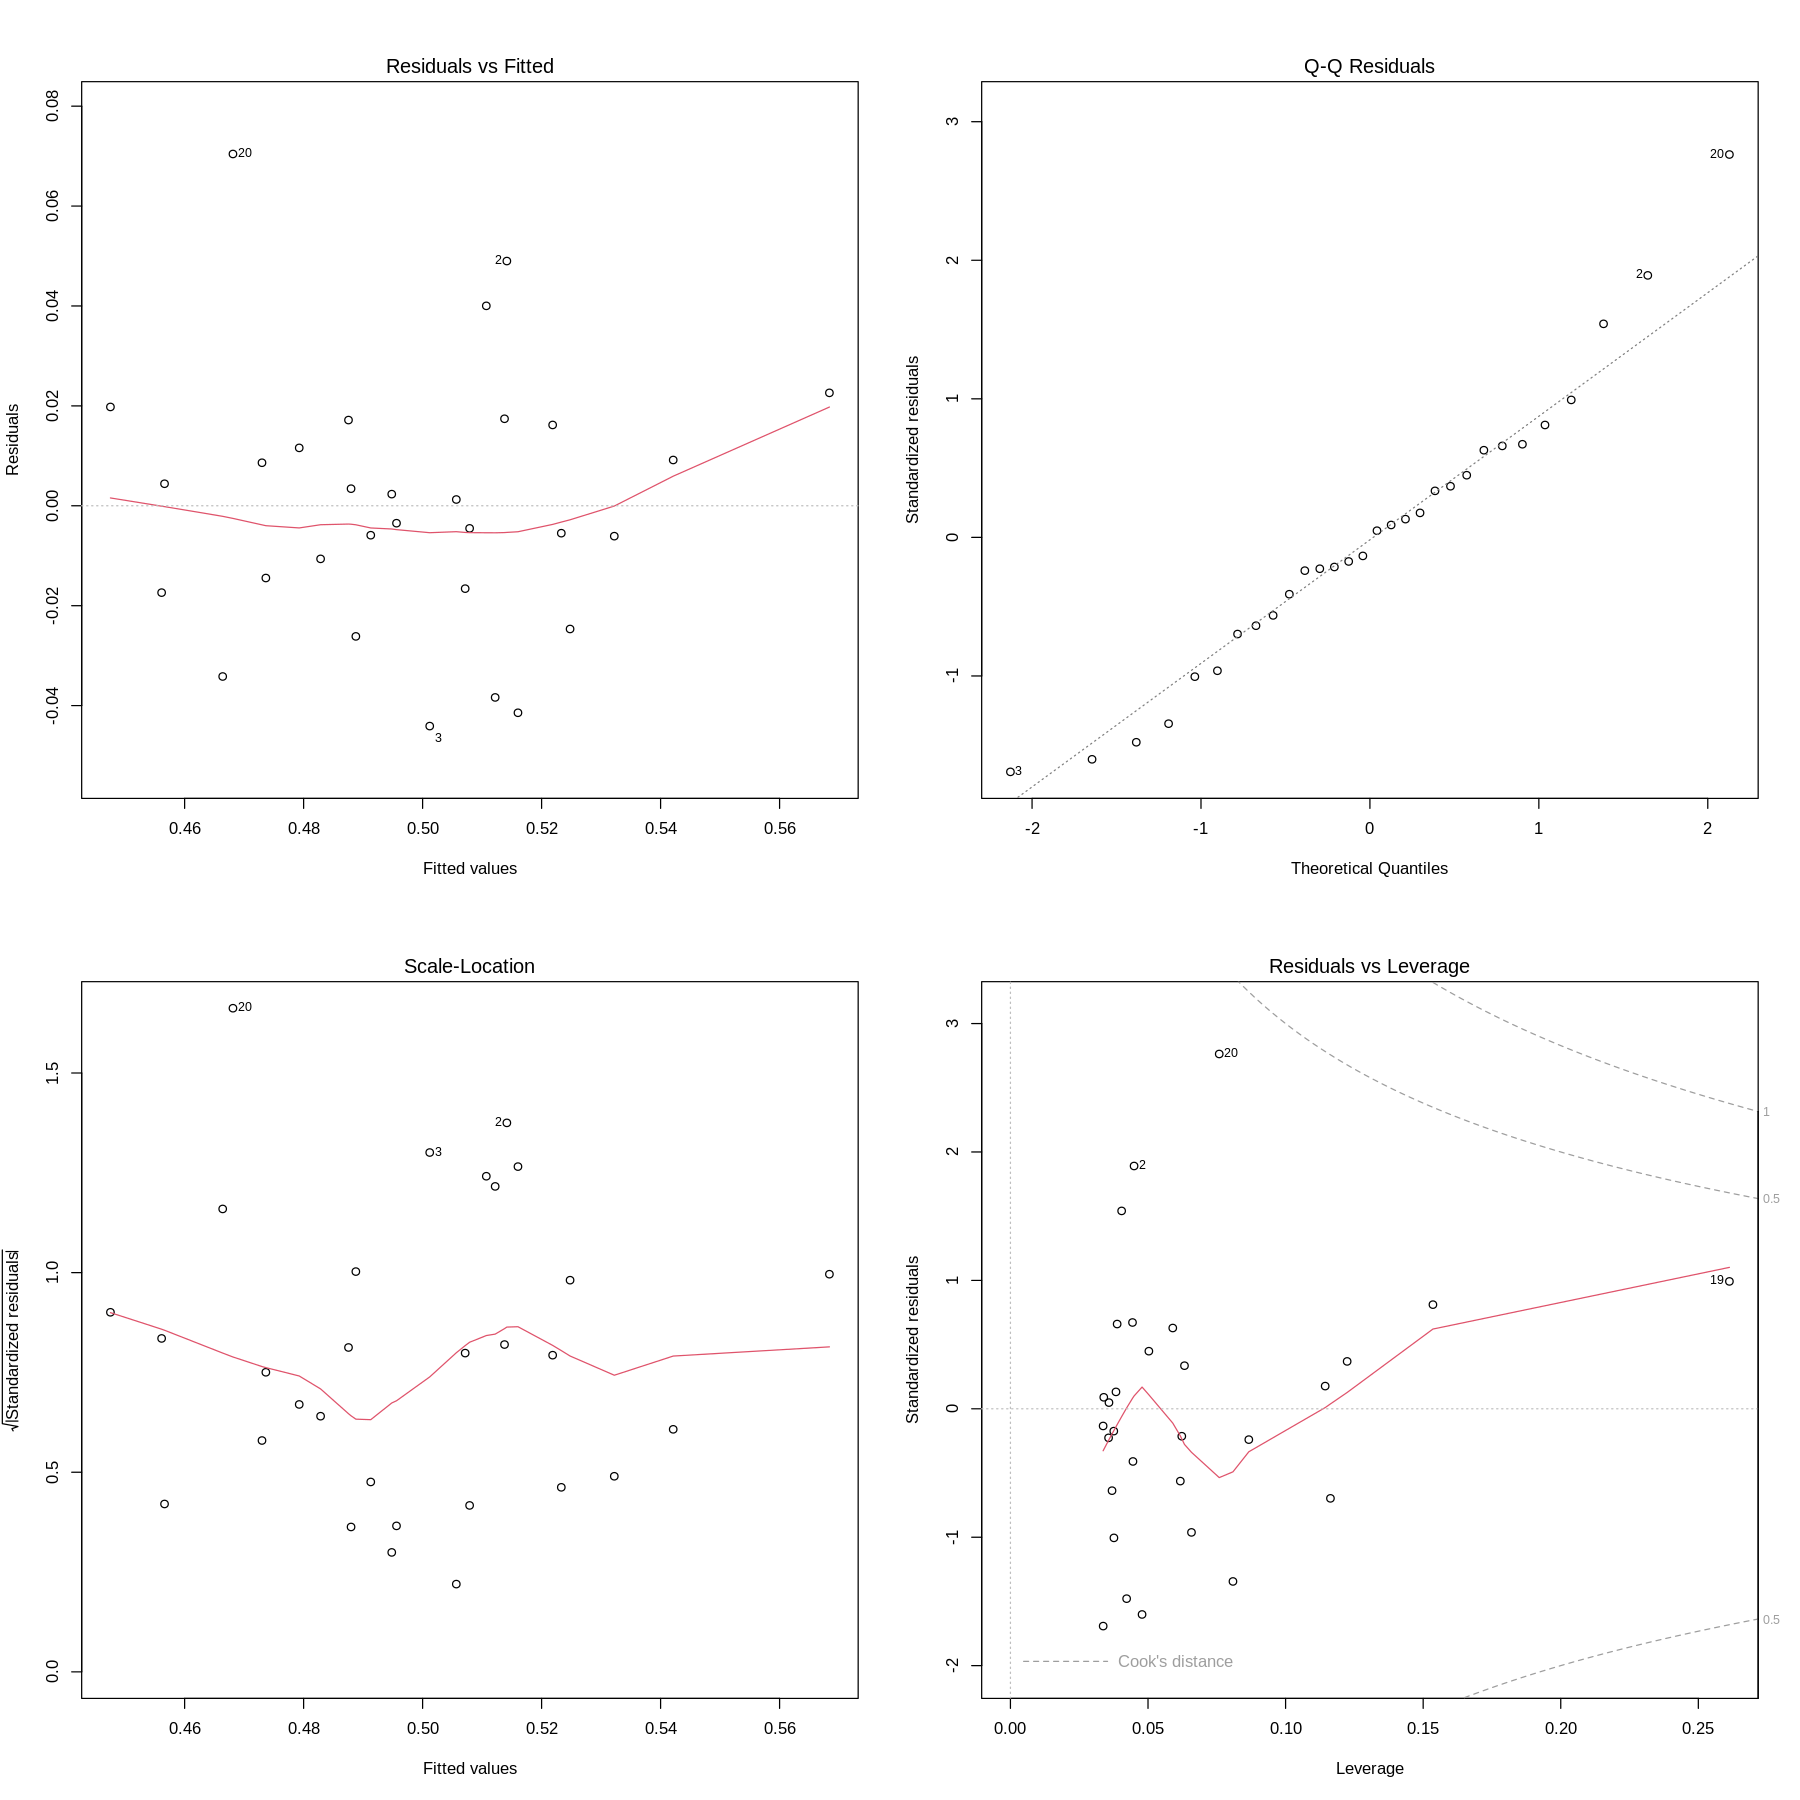

In [68]:
lm_log <- lm(pct_wins_aggregate ~ log(payroll_aggregate), data = mlb_aggregate)
summary(lm_log)

par(mfrow = c(2,2))
plot(lm_log)


Compare R² and residual behavior.

R² original is 0.5447 while R² when payroll undergoes a log transformation is 0.522.

Does the transformation improve the model?

The transformation does not appear to imporve the model since R² decreased and QQ plot still has deviation in the upper tail.

5.2 Efficiency Metric (2 points)
Define efficiency:

Efficiency=PayrollWin Percentage​

Identify top 3 most efficient teams.

In [69]:
mlb_aggregate <- mlb_aggregate %>%
  mutate(efficiency = pct_wins_aggregate / payroll_aggregate)

top3_efficient <- mlb_aggregate %>%
  arrange(desc(efficiency)) %>%
  select(team, payroll_aggregate, pct_wins_aggregate, efficiency) %>%
  slice(1:3)

top3_efficient

team,payroll_aggregate,pct_wins_aggregate,efficiency
<fct>,<dbl>,<dbl>,<dbl>
Miami Marlins,698.0929,0.4673161,0.0006694182
Oakland Athletics,887.5729,0.5385489,0.0006067658
Tampa Bay Rays,776.1869,0.4610341,0.0005939731


Discuss whether efficiency aligns with regression results.

Efficiency shows which teams have the most wins per money spent. This contrasts with the regression results which shows that wwins increase with payroll increase, as efficiency focuses on achieving more wins for less spending.


Relate findings briefly to the Moneyball concept.

Moneyball concept is using undervalued players to compete with teams who have a higher budget. This aligns with efficiency, as it places emphasis on teams that achieve good winning percentage despite limited payroll.